# HSE 2024: Mathematical Methods for Data Analysis

## Homework 3

**Warning 1**: some problems require (especially the lemmatization part) significant amount of time, so **it is better to start early (!)**

**Warning 2**: it is critical to describe and explain what you are doing and why, use markdown cells

Импортируем многие модули/библиотеки

In [ ]:
from typing import Tuple, List

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
%matplotlib inline

sns.set(style="darkgrid")

## PART 1: Logit model

We consider a binary classification problem. For prediction, we would like to use a logistic regression model. For regularization we add a combination of the $l_2$ and $l_1$ penalties (Elastic Net).

Each object in the training dataset is indexed with $i$ and described by pair: features $x_i\in\mathbb{R}^{K}$ and binary labels $y_i$. The model parametrized with bias $w_0\in\mathbb{R}$ and weights $w\in\mathbb{R}^K$. Note: Bias is included in $w$ vector

The optimization problem with respect to the $w_0, w$ is the following (Logistic loss with Elastic Net regularizers):

$$L(w, w_0) = \sum_{i=1}^{N} -y_i \log{\sigma{(w^\top x_i)}} - (1 - y_i) \log{(1 - \sigma{(w^\top x_i)})} + \gamma \|w\|_1 + \beta \|w\|_2^2$$

#### 1. [0.5 points]  Find the gradient of the Elastic Net loss and write its formulas (better in latex format). Remember what derivative sigmoid has (gradient in fact is a lot simpler than you may get using automatic tools like sympy, matlab or whatever)

Детальное пояснение (по строчкам):
1. Записали произодную суммы как сумму производных (но вообще формально это не производная, т.к d(W) - некорректная запись - ведь W это вектор. Но в дальнейших записях будут коэф-ты i, то есть мы как-бы считаем производную для каждого i.)
2. Выносим константы, и можем сразу посчитать производную для l1 метрики
3. Пользуемся формулой производной сложной суммы.
4. Считаем производные логарифмов. Пользуемся формулой производной сложной суммы.
5. Выносим общий множитель
6. Расписываем функцию сигмоиду
7. Сокращаем дроби в левой части
8. Раскладываем и сокращаем слагаемые
9. Приводим к конечному виду

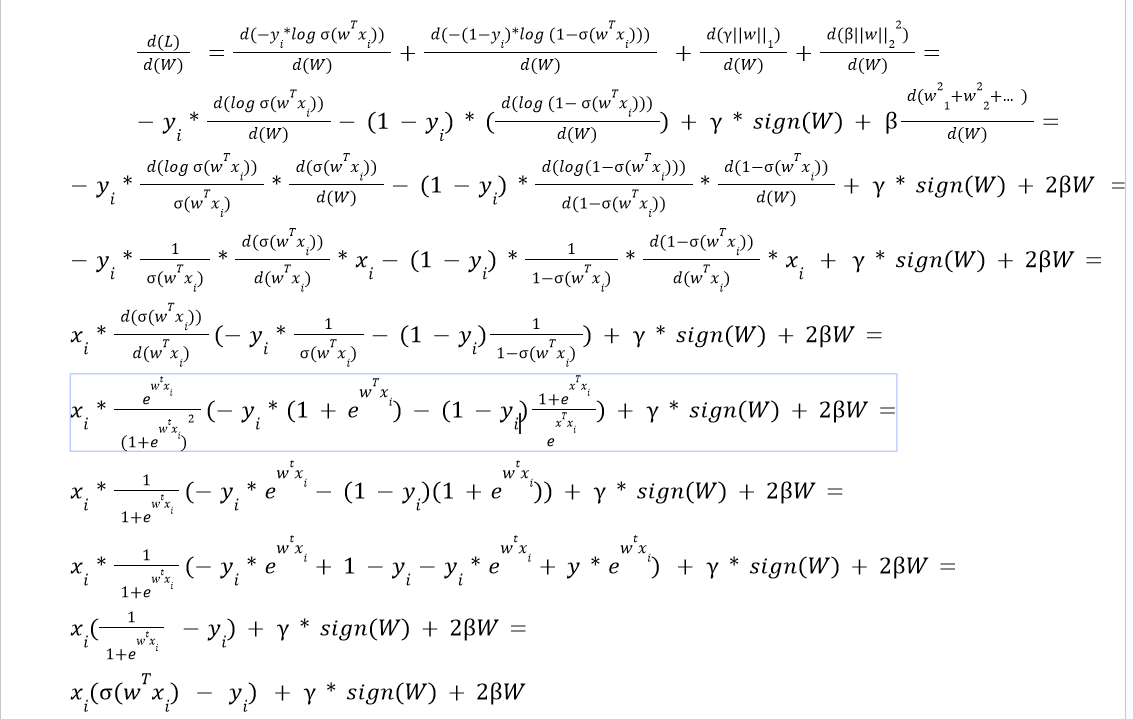

Ну и соответсвенно на это все будет навешана сигмоида заглавная, т.к мы считаем сумму

#### 2. [0.25 points] Implement the Elastic Net loss (as a function)

По формуле просто посчитаем loss

In [ ]:
import math

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def loss(X, y, w: List[float], gamma=1., beta=1.) -> float:
    pred = sigmoid(X @ w)
    x1 = -y*np.log(pred)
    x2 = -(1-y)*np.log(1-pred)
    l1 = gamma * np.abs(w)
    l2 = beta * w * w
    result = np.sum(x1+x2) + np.sum(l1+l2)
    return result

#### 3. [0.25 points] Implement the gradient (as a function)

Реализуем ту формулу, которую получили ранее

In [ ]:
def get_grad(X, y, w: List[float], gamma=1., beta=1.) -> Tuple[List[float], float]:
    grad_w = X.T @ (sigmoid(X @ w) - y) + gamma*np.sign(w) + 2*beta*w
    return grad_w

#### Check yourself

In [ ]:
np.random.seed(42)
X = np.random.multivariate_normal(np.arange(5), np.eye(5), size=10)
X = np.c_[np.ones(X.shape[0]), X]
y = np.random.binomial(1, 0.42, size=10)
w = np.random.normal(size=5 + 1)

grad_w = get_grad(X, y, w)
assert(np.allclose(grad_w,
                   [-3.99447493, -1.84786723,  0.64520104,  1.67059973, -5.03858487, -5.21496336],
                   rtol=1e-2)
)

####  4. [1 point]  Implement gradient descent which works for both tol level and max_iter stop criteria and plot the decision boundary of the result

В ```__init__``` сохраним некоторые параметры модели.

В ```fit()``` для X приписываем единицы к кажому входу (что обозначает смещение). Сохраняем loss, следим чтобы норма разности векторов не была меньше ```tolerance```.
В ```predict()``` предсказываем результат для X без округления. (Для красивого графика далее).
В ```grad_step()``` просто пользуемся предыдущими вычислениями.  

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

In [ ]:
class Logit(BaseEstimator, ClassifierMixin):
    def __init__(self, beta=1.0, gamma=1.0, lr=1e-3, tolerance=0.01, max_iter=1000, random_state=42):
        self.beta = beta
        self.gamma = gamma
        self.tolerance= tolerance
        self.max_iter= max_iter
        self.learning_rate = lr
        self.random_state = random_state
        self.w = None
        self.w_previous = None

        self.loss_history = []
        self.input_size = X.shape[1]

    def fit(self, X, y):
        self.w = np.random.normal(0, 1, size = self.input_size + 1)
        X = np.c_[np.ones(X.shape[0]), X]

        for epoch in range(self.max_iter):
            self.grad_step(X, y)
            self.loss_history.append(loss(X, y, self.w, self.gamma, self.beta))
            if epoch != 0 and self.tolerance > np.linalg.norm(self.w - self.w_previous):
                break
            self.w_previous = self.w.copy()

        return self

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        return sigmoid(X @ self.w)

    def predict_proba(self, X):
        return np.array([1 / (1 + np.exp(np.dot(X, self.w))),\
                         1 / (1 + np.exp(-np.dot(X, self.w)))])

    def grad_step(self, X, y):
        grad = get_grad(X, y, self.w)
        self.w -= self.learning_rate * grad

In [ ]:
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=180, n_features=2, n_redundant=0, n_informative=2,
                               random_state=42, n_clusters_per_class=1)

Функция взята из семинара. Строит предсказания модели для 2 входных параметров и строит прямую регрессии.

In [ ]:
def plot_decision_boundary(model, X, y):
    fig, ax = plt.subplots()
    X1min, X2min = X.min(axis=0)
    X1max, X2max = X.max(axis=0)
    x1, x2 = np.meshgrid(np.linspace(X1min, X1max, 200),
                         np.linspace(X2min, X2max, 200))
    ypred = model.predict(np.c_[x1.ravel(), x2.ravel()])
    ypred = ypred.reshape(x1.shape)

    ax.set(xlabel='x1', ylabel='x2',
       title='Регрессионная прямая')

    plt.contourf(x1, x2, ypred, alpha=.5)
    plt.scatter(X[:,0], X[:,1], c=y)

In [ ]:
print(X.shape)

(180, 2)


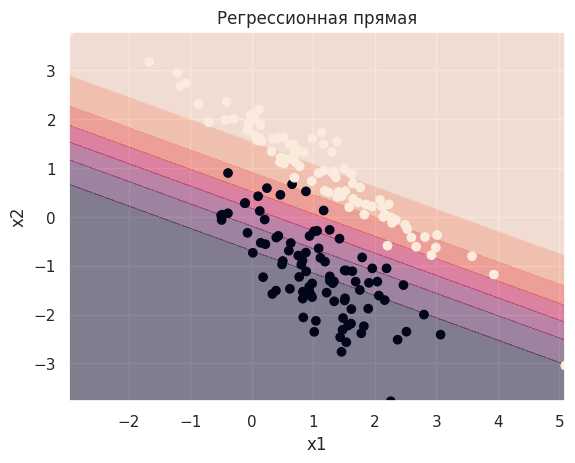

In [ ]:
model = Logit(0, 0)
model.fit(X, y)
plot_decision_boundary(model, X, y)

Грфик взят из семинара. На нем X и Y оси соответсвуют 2 входным значениям для сетки. Соттветсвенно обрезаем до нужных данных и строим регрессионную прямую.
Как мы видим, пряммая весьма хорошо разделяет точки на 2 части. Не соответсвующие регресии значения скорее аномальные.

Вывод: самая простая модель, состоящая из 2 входных нейронов, одного смещения и сигмоиды как функции активации хорошо справляется с  задачей деления объектов на 2 класса. Переобучение модель не проверяет, ибо классы распределены интуитивно понятно.

#### 5. [0.25 points] Plot loss diagram for the model, i.e. show the dependence of the loss function from the gradient descent steps

Построим простую зависимость значения функции потери от эпохи

In [ ]:
def plot_loss_history(loss_history):
    epoches = list(range(1, len(loss_history)+1))

    fig, ax = plt.subplots()
    ax.plot(epoches, loss_history)

    ax.set(xlabel='Эпоха', ylabel='Loss',
       title='Loss обучаемой модели')
    ax.grid()

    plt.show()

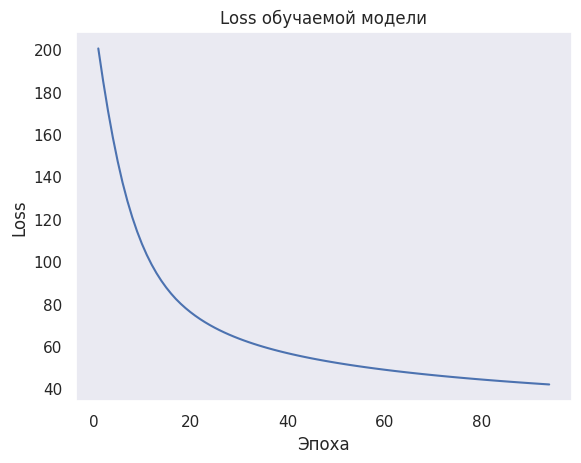

In [ ]:
plot_loss_history(model.loss_history)

## PART 2: Support Vector Machines

#### 6. [2 point] Using the same dataset, train SVM Classifier from Sklearn.
Investigate how different parameters influence the quality of the solution:
+ Try several kernels: Linear, Polynomial, RBF (and others if you wish). Some Kernels have hypermeters: don't forget to try different.
+ Regularization coefficient

Show how these parameters affect accuracy, roc_auc and f1 score.
Make plots for the dependencies between metrics and parameters.
Try to formulate conclusions from the observations. How sensitive are kernels to hyperparameters? How sensitive is a solution to the regularization? Which kernel is prone to overfitting?

Импортируем нужное

In [ ]:

from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_auc_score
from matplotlib.pyplot import figure

Получим данные и разделим на обучающую и тестовые выборки стандартным способом

In [ ]:
X, y = make_classification(n_samples=180, n_features=2, n_redundant=0, n_informative=2, random_state=42, n_clusters_per_class=1)
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

Сделаем 3 функции для получения 3 разных моделей. Суть в том, что разные модели (ядра) требуют разное кол-во коэфициентов. Учтем это:

In [ ]:
def get_trained_model_linear(reg_coef):
    model = SVC(verbose = False, probability = True, kernel = 'linear', C = reg_coef)
    model.fit(x_train, y_train)
    return model

def get_trained_model_polynomial(reg_coef, gamma, degree):
    model = SVC(verbose = False, probability = True, kernel = 'poly', C = reg_coef, gamma=gamma, degree=degree)
    model.fit(x_train, y_train)
    return model

def get_trained_model_rbf(reg_coef, gamma):
    model = SVC(verbose = False, probability = True, kernel = 'rbf', C = reg_coef, gamma=gamma)
    model.fit(x_train, y_train)
    return model

Фнкция получения точности

In [ ]:
def get_accuracy(name, out, gt):
    if (name == 'accuracy'):
        return accuracy_score(gt, out)
    elif (name == 'f1'):
        return f1_score(gt, out)
    else:
        return roc_auc_score(gt, out)

Фнкция, которая строит график

In [ ]:
def plot_params_comparison(kernel, acc):
    reg_coefs = np.arange(0.01, 6.0, 0.05)
    accs_train = []
    accs_test = []

    if (kernel == 'linear'):
        for reg_coef in reg_coefs:
            model = get_trained_model_linear(reg_coef)
            acc_train_value = get_accuracy(acc, model.predict(x_train), y_train)
            acc_test_value = get_accuracy(acc, model.predict(x_test), y_test)
            accs_train.append(acc_train_value)
            accs_test.append(acc_test_value)
    elif (kernel == 'poly'):
        for reg_coef in reg_coefs:
            model = get_trained_model_polynomial(reg_coef, 0.5, 2)
            acc_train_value = get_accuracy(acc, model.predict(x_train), y_train)
            acc_test_value = get_accuracy(acc, model.predict(x_test), y_test)
            accs_train.append(acc_train_value)
            accs_test.append(acc_test_value)
    else:
        for reg_coef in reg_coefs:
            model = get_trained_model_rbf(reg_coef, 0.5)
            acc_train_value = get_accuracy(acc, model.predict(x_train), y_train)
            acc_test_value = get_accuracy(acc, model.predict(x_test), y_test)
            accs_train.append(acc_train_value)
            accs_test.append(acc_test_value)

    figure(figsize=(13, 8), dpi=80)
    plt.plot(reg_coefs, accs_train)
    plt.plot(reg_coefs, accs_test)

    plt.legend()
    plt.grid(True)
    plt.show()

Построим 3 графика для 3 ядер и посмтрим разные метрики. Видно, что Poly ядро очень сильно зависим от метрик и работает на маленьких показателях. Дальше как будто переобчается. Остальные лучше работают на больших значениях

In [ ]:
plot_params_comparison('linear', 'accuracy')

In [ ]:
plot_params_comparison('poly', 'f1')

In [ ]:
plot_params_comparison('rbf', 'roc_auc')

NameError: name 'plot_params_comparison' is not defined

## PART 3: Natural Language Processing

#### 7. [1.75 point] Form the dataset

We are going to form a dataset that we will use in the following tasks for binary and multiclass classification

0. Choose **six** authors that you like (specify who you've chosen) and download the <a href="https://www.kaggle.com/d0rj3228/russian-literature?select=prose">relevant data</a> from **prose** section
1. Build your own dataset for these authors:
    * divide each text into sentences such that we will have two columns: *sentence* and *target author*, each row will contain one sentence and one target
    * drop sentences where N symbols in a sentence < 15
    * fix random state and randomly choose sentences in the folowing proportion "5k : 15k : 8k : 11k : 20k : 3k" for the authors respectively
    
    sample data may look like:
    
    <center>
    <table>
        <tr>
            <th> sentence </th>
            <th> author </th>
        </tr>
        <tr><td> Несколько лет тому назад в одном из своих поместий жил старинный русской барин, Кирила Петрович Троекуров. </td><td> Пушкин </td><td>
        <tr><td> Уже более недели приезжий господин жил в городе, разъезжая по вечеринкам и обедам и таким образом проводя, как говорится, очень приятно время. </td><td> Гоголь </td><td>
        <tr><td> ... </td><td> ... </td><td>
        <tr><td> Я жил недорослем, гоняя голубей и играя в чехарду с дворовыми мальчишками. </td><td> Пушкин </td><td>         
    </table>
</center>
     
2. Preprocess (tokenize and clean) the dataset
    * tokenize, remove all stop words (nltk.corpus.stopwords), punctuation (string.punctuation) and numbers
    * convert to lower case and apply either stemming or lemmatization of the words (on your choice)
    * vectorize words using both **bag of words** and **tf-idf** (use sklearn)
    * observe and describe the difference between vectorized output (what do numbers look like after transformations and what do they represent?)

Скачиваем круасан для скачивая данных в kaggle

In [ ]:
!pip install mlcroissant

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.5/136.5 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 562.4/562.4 kB 15.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 2.7 MB/s eta 0:00:00
  Created wheel for jsonpath-rw: filename=jsonpath_rw-1.4.0-py3-none-any.whl size=15130 sha256=4517f021e25acd04dfa515043d1441f027caafd4d222c129ce7987d916cf90f7
  Stored in directory: /root/.cache/pip/wheels/e3/76/6f/c25be6a9e6cc9985b96e8c95997d46790242c6426ef68e754c
Successfully built jsonpath-rw


Скачиваем датасет

In [ ]:
!rm -rf data

In [ ]:
#!/bin/bash
!kaggle datasets download d0rj3228/russian-literature

Dataset URL: https://www.kaggle.com/datasets/d0rj3228/russian-literature
License(s): ODC Public Domain Dedication and Licence (PDDL)
 92% 19.0M/20.5M [00:00<00:00, 194MB/s]
100% 20.5M/20.5M [00:00<00:00, 196MB/s]


Распаковываем с кодировкой utf-8, т.к текст на русском и кодировку в таком случае задать надо явно.

In [ ]:
!unzip -O 'utf-8' russian-literature.zip -d data

Archive:  russian-literature.zip
  inflating: data/README.md          
  inflating: data/Tolstoy_and_Chekhov_1901.jpg  
  inflating: data/poems/Blok/info.csv  
  inflating: data/poems/Blok/Возмездие.txt  
  inflating: data/poems/Blok/Двенадцать.txt  
  inflating: data/poems/Blok/Корреспонденция Бальмонта из Мексики.txt  
  inflating: data/poems/Blok/Скифы.txt  
  inflating: data/poems/Blok/Соловьиный сад.txt  
  inflating: data/poems/Blok/Стихотворения 1897-1903 гг, не вошедшие в основное собрание.txt  
  inflating: data/poems/Blok/Стихотворения. Книга вторая (1904-1908).txt  
  inflating: data/poems/Blok/Стихотворения. Книга первая (1898-1904).txt  
  inflating: data/poems/Blok/Стихотворения. Книга третья (1907-1916).txt  
  inflating: data/poems/Blok/Шуточные стихи и сценки.txt  
  inflating: data/poems/Lermontov/А. О. Смирновой.txt  
  inflating: data/poems/Lermontov/Аминт твой на глупца походит....txt  
  inflating: data/poems/Lermontov/Ангел.txt  
  inflating: data/poems/Lermontov

In [ ]:
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

Я выбрал на рандоме авторов Тургенев, Пушкин, Лермонтов, Гоголь, Достоевский.

Далее кажый текст делим на предложения и те, в которых более 15 символов, добавляем в pandas - таблицу.

In [ ]:
import os
import glob
from tqdm import tqdm

authors = ['Turgenev', 'Bryusov', 'Pushkin', 'Lermontov', 'Gogol', 'Dostoevsky']
df = pd.DataFrame(columns=['sentence', 'author'])

for author in authors:
    print(author)
    path = os.path.join('data', 'prose')
    path = os.path.join(path, author)
    all_texts = glob.glob(f"{path}/*.txt")
    print(len(all_texts))
    for text_path in all_texts:
        with open(text_path) as f:
             text = f.read()
             sentences = nltk.sent_tokenize(text, language='russian')
             dicts = []
             for sentence in tqdm(sentences):
                # print(sentence)
                # print(author)
                if (len(str(sentence)) >= 15):
                    dicts.append({'sentence': sentence, 'author': author})
             new_line = pd.DataFrame(dicts)
             df = pd.concat([df, new_line], ignore_index=True)
             dicts = []

Turgenev
10


100%|██████████| 1019/1019 [00:00<00:00, 335847.54it/s]


Bryusov
30


100%|██████████| 2018/2018 [00:00<00:00, 359562.68it/s]


Pushkin
10


...

100%|██████████| 309/309 [00:00<00:00, 528133.63it/s]


Gogol
16


100%|██████████| 3442/3442 [00:00<00:00, 504571.31it/s]


Dostoevsky
33


100%|██████████| 428/428 [00:00<00:00, 529702.60it/s]


Проверяем, что все разделилось - выведем шапку таблицы

In [ ]:
df.head(10)

,sentence,author
0,Иван Тургенев\nМУМУ\nВ одной из отдаленных ули...,Turgenev
1,"Сыновья ее служили в Петербурге, дочери вышли ...",Turgenev
2,"День ее, нерадостный и ненастный, давно прошел...",Turgenev
3,Из числа всей ее челяди самым замечательным ли...,Turgenev
4,"Барыня взяла его из деревни, где он жил один, ...",Turgenev
5,"Одаренный необычайной силой, он работал за чет...",Turgenev
6,Постоянное безмолвие придавало торжественную в...,Turgenev
7,"Славный он был мужик, и не будь его несчастье,...",Turgenev
8,Крепко не полюбилось ему сначала его новое житье.,Turgenev
9,"С детства привык он к полевым работам, к дерев...",Turgenev


Посмотрим, какое кол-во предложений имеет каджый автор в таблице

In [ ]:
author_count = []
for author in authors:
    print(f"{author}: {df[df['author'] == author].shape[0]}")
    author_count.append(df[df['author'] == author].shape[0])

Turgenev: 24793
Bryusov: 24041
Pushkin: 10141
Lermontov: 3022
Gogol: 23640
Dostoevsky: 110919


Далее понятно, что если мы хоти поделить всех авторов в определенных пропорциях и удалить как можно меньшее кол-во данных, то порядковые номера кофэ-ов пропорции должны соответсвовать порядковым номерам кол-ва предложений у авторов. Значит, раз кол-во предложений соответственно (24793, 24041, 10414, 3222, 23640, 110919), то коэф-ты соответсвенно должны быть (15, 11, 5, 3, 8, 20)

In [ ]:
coefs = [15, 11, 5, 3, 8, 20]
k = int(np.min(np.array(author_count) / np.array(coefs)))

df_sampled = pd.DataFrame(columns=['sentence', 'author'])

for i in range(6):
    author_sampled = df[df['author'] == authors[i]].sample(n=k*coefs[i], random_state=42)
    df_sampled = pd.concat([df_sampled, author_sampled], ignore_index=True)

Выведем, сколько теперь у каждого автора предложений.

In [ ]:
author_count = []
for author in authors:
    print(f"{author}: {df_sampled[df_sampled['author'] == author].shape[0]}")
    author_count.append(df_sampled[df_sampled['author'] == author].shape[0])

Turgenev: 15105
Bryusov: 11077
Pushkin: 5035
Lermontov: 3021
Gogol: 8056
Dostoevsky: 20140


Установим библиотеку, в которой есть морфологический анализатор

In [ ]:
!pip install pymorphy2

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.5/55.5 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 52.7 MB/s eta 0:00:00
  Created wheel for docopt: filename=docopt-0.6.2-py2.py3-none-any.whl size=13706 sha256=8b25f6714dba939eb0995c3deeaf84ab4ad698ebf89aba216f318f1093fb19b7
  Stored in directory: /root/.cache/pip/wheels/fc/ab/d4/5da2067ac95b36618c629a5f93f809425700506f72c9732fac
Successfully built docopt


Сделаем импорты и вспомогательные переменные

In [ ]:
word_tokenizer = nltk.WordPunctTokenizer()
import string
import nltk
nltk.download('stopwords')
stop_words = nltk.corpus.stopwords.words('russian')
dates = [str(x) for x in np.arange(1900, 2022)]
import pymorphy2
morphius = pymorphy2.MorphAnalyzer()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
print(string.punctuation)

!"#$%&'()*+,-./:;<=>?@[\]^_`{|}~


Далее приведем все к нижнему регистру, поделим на токены предложения и удалим лишние и приведем к нормальным формам (то есть каждое слово заменим на более простое, не теряя смысл). Не забудем обратно их собрать в предложения.

In [ ]:
from tqdm import tqdm

X = []
y = []

df_sentence_list = list(df_sampled['sentence'])
df_authors_list = list(df_sampled['author'])
#print(df_list[0:8])
for i in tqdm(range (len(df_authors_list))):
    #print(sentence)
    text_lower = df_sentence_list[i].lower()
    tokens = word_tokenizer.tokenize(text_lower)
    tokens = [word for word in tokens if (word not in string.punctuation and word not in stop_words and word not in dates)]
    for j in range(len(tokens)):
        tokens[j] = morphius.parse(tokens[j])[0].normal_form
    X.append(' '.join(tokens))
    y.append(df_authors_list[i])

100%|██████████| 62434/62434 [04:13<00:00, 246.32it/s]


In [ ]:
print(len(X))
print(len(y))

62434
62434


Далее нам надо каждое предложение привести к вектору. Для этого имеется два подхода:
1. Использовать CountVectorizer. Ему мы задаем размер вектора n для каждого предложения (кол-во встречаемости каждого из n каких-то слов). Такой подход имеет много минусов. В нем учитывается только частота встречаемости слов. Но набор слов в текстах может быть весьма огромный, а делать кол-во признаков очень бльшим тоже весьма неэффективно (ведь наша модель весьма простая, и в таком случае будут нейроны которые будут лишь сбивать с тольку нейронку, например незначащие слова). Также плохо работает предсказание. Если предложение будет состоять из простых слов, но при этом иметь свой стиль или любые другие отличающие факторы, то модель этого не поймет и будет работать плохо, даже рандомно
2. Использовать TfidfVectorizer. Все так же выбирает константно слова, но для каждого считает его важность в предложении. То есть считает частоту встречаемости слова в тексте и частоту во всех текстах (то есть то, как это слово важно именно в этом тесте по сравнению со всеми). По сути сохраняется проблема того что мы предсказываем автора зная информацию о частоте встречаемости определенного набора слов. Однако в данном методе вместо целых чисел дробные, что делает наборы данных более вариативным. Но тут признаки отражают то, как часто встречаются предложения с этим словом. Это позволит разделить ситуацииб когда автор употреляет слово много раз в одном предложении или часто всегда.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer(max_features = 50)
vectorizer.fit(X)
X_c = vectorizer.transform(X)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(max_features = 100)
vectorizer_tfidf.fit(X)
X_tfidf = vectorizer_tfidf.transform(X)

In [ ]:
X_c.todense().shape

(62434, 50)

In [ ]:
X_tfidf.todense().shape

(62434, 100)

In [ ]:
X_tfidf.todense().shape

(62434, 100)

In [ ]:
len(y)

62434

In [ ]:
X_tfidf[42]

<1x100 sparse matrix of type '<class 'numpy.float64'>'
	with 0 stored elements in Compressed Sparse Row format>

###  Binary classification

#### 8. [2 point] Train model using Logistic Regression (your own) and SVC (SVM can be taken from sklearn)

* choose *two* authors from the dataset that you have formed in the previous task
* check the balance of the classes
* divide the data into train and test samples with 0.7 split rate (don't forget to fix the random state)
* using GridSearchCV - find the best parameters for the models (by F1 score) and use it in the next tasks
* make several plots to address the dependence between F1 score and parameters
* plot confusion matrix for train and test samples
* compute some relevant metrics for test sample (useful to check the seminars 5 and 6, use sklearn)
* make conclusions about the performance of your models


Давайте выберем Тургенева и Достоевского. Можно было бы выбрать любую другую пару, у которой отношение классов было бы меньше, но именно у этих авторов больше всего предложений (т.е больше обучающая выборка), и как на мой взгляд более приблеженная к жизни ситуация, когда балланс не совсем соблюдается. Тут отношение примерно 43% к 57% соответстенно. Весьма сбалансированно

In [ ]:
# Turgenev, Dostoevsky
authoes_indexes = [i for i in range(len(X)) if y[i] == 'Turgenev' or y[i] == 'Dostoevsky']
X = [ X[i] for i in authoes_indexes ]
y = [ y[i] for i in authoes_indexes ]

In [ ]:
print(y.count('Turgenev'))
print(y.count('Dostoevsky'))

15105
20140


Разделим на 2 выборки, y будет вектором из 0 и 1, т.к предсказываем всего 2 класса.

In [ ]:
from sklearn.model_selection import train_test_split
train_texts, test_texts, y_train, y_test = train_test_split(X, [1 if a == 'Dostoevsky' else 0 for a in y ] , test_size=0.3, random_state=42, stratify = y, shuffle=True)

In [ ]:
print(train_texts[0:10])
print(y_train[0:10])
print(train_texts[-6:-1])
print(y_train[-6:-1])

['потрясти испугать', 'подобный преодоление убеждение сколь успешный лишь проявление зло особенно завуалированный одежда добропорядочность быть открыто обнажаться душа человек откладываться слой благопристойный форма глубина дно', 'этот женщина который колено становиться перед я гордый', 'поднять голова удвоенный внимание посмотреть чудак', 'увидеть милостивый народ наш благодарный отблагодарить сто крат помнить радение иерей умилённый слово помочь нива добровольно помочь дом уважение воздать больший прежний – увеличиться содержание', 'нисколько сомневаться это бред правда стать цыпочка разглядеть скорый голова человек – такой нести', '– какой чудесный облако', 'застать ася', 'пристяжной ёжиться фыркать щеголеватый переступать нога пара проснуться белый гусь молча медленно перебираться дорога', 'это остаться сказать один упрямство самолюбие самый де грие явиться ореол изящный маркиз разочаровать либерал разориться']
[1, 1, 0, 0, 1, 1, 0, 0, 0, 1]
['быть означать стон крик облечься стих

Используем TfidfVectorizer, про который мы сказали ранее, что он лучше. Обучим на тестовой выборке и применим для всей

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer(max_features = 100)
vectorizer_tfidf.fit(train_texts)
X_train_tfidf = vectorizer_tfidf.transform(train_texts)
X_test_tfidf = vectorizer_tfidf.transform(test_texts)

Тут я вынес все это отдельно, хотя класс и методы закодил ранее, т.к тестировал отдельно + есть небольшие изменения под эту задачу

In [ ]:
from sklearn.base import BaseEstimator, ClassifierMixin

import math

def sigmoid(x):
  return 1 / (1 + np.exp(-x))

def loss(X, y, w: List[float], gamma=1., beta=1.) -> float:
    pred = sigmoid(X @ w)
    x1 = -y*np.log(pred)
    x2 = -(1-y)*np.log(1-pred)
    l1 = gamma * np.abs(w)
    l2 = beta * w * w
    result = np.sum(x1+x2) + np.sum(l1+l2)
    return result

def get_grad(X, y, w: List[float], gamma=1., beta=1.) -> Tuple[List[float], float]:
    #print(X.shape)
    #print((sigmoid(X @ w) - y).shape)
    grad_w = X.T @ (sigmoid(X @ w) - y) + gamma*np.sign(w) + 2*beta*w
    return grad_w

class LogitNlp(BaseEstimator, ClassifierMixin):
    def __init__(self, beta=1.0, gamma=1.0, lr=1e-3, tolerance=0.01, max_iter=500, random_state=42, X_size=100):
        self.beta = beta
        self.gamma = gamma
        self.tolerance= tolerance
        self.max_iter= max_iter
        self.learning_rate = lr
        self.random_state = random_state
        self.w = None
        self.w_prev = None
        np.random.seed(random_state)
        self.loss_history = []

    def fit(self, X, y):
        self.w = np.random.normal(0, 1, size = X.shape[1] + 1)
        X = np.c_[np.ones(X.shape[0]), X]

        for epoch in range(self.max_iter):
            self.grad_step(X, y, self.gamma, self.beta)
            #print(epoch)
            #print(self.w)
            #print(f1_score(y, model.predict(X)))
            self.loss_history.append(loss(X, y, self.w, self.gamma, self.beta))
            if epoch != 0 and self.tolerance > np.linalg.norm(self.w - self.w_prev):
                break
            self.w_prev = self.w.copy()

        return self

    def predict(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        return np.round(sigmoid(X @ self.w))

    def predict_proba(self, X):
        X = np.c_[np.ones(X.shape[0]), X]
        probs = sigmoid(sigmoid(X @ self.w))
        return np.vstack([1 - probs, probs]).T

    def grad_step(self, X, y, gamma, betta):
        grad = get_grad(X, y, self.w, gamma, betta)
        #print(grad)
        self.w -= self.learning_rate * grad

Некоторые вспомогательные функции, чтобы етсттировать все это многократно

In [ ]:
def train_nlp_model(X_train_tfidf, X_test_tfidf, y_train, y_test, betta = 1.0, gamma = 1.0):
    model = get_nlp_model(X_train_tfidf, X_test_tfidf, y_train, y_test, betta = betta, gamma = gamma)
    model.fit(np.array(X_train_tfidf.todense()), np.array(y_train))

    #print(model.loss_history)
    score1 = model.predict(np.array(X_test_tfidf.todense()))
    score2 = model.predict(np.array(X_train_tfidf.todense()))
    print(f1_score(y_test, score1))

    return model

In [ ]:
def get_nlp_model(X_train_tfidf, X_test_tfidf, y_train, y_test, betta = 1.0, gamma = 1.0):
    return LogitNlp(beta=betta, gamma=gamma, lr=1e-4, tolerance=0.0001)

In [ ]:
def get_model_f1(model, x, y):
    pred = model.predict(x)
    return f1_score(y, pred)

In [ ]:
print(X_train_tfidf.todense().shape)
print(len(y_train))

(24671, 100)
24671


По итогу метод выводит f1_score для модели

In [ ]:
model = train_nlp_model(X_train_tfidf, X_test_tfidf, y_train, y_test)

[18910.36330511282, 18877.95227122104, 18847.972538632246, 18818.794592733513, 18790.075637960857, 18761.745553194283, 18733.773781164495, 18706.15133177393, 18678.87177804153, 18651.92933244672, 18625.318447618534, 18599.03373076905, 18573.06992265639, 18547.421889889723, 18522.109254105057, 18497.143217455752, 18472.47610448674, 18448.103321768205, 18424.020378915946, 18400.222884717507, 18376.706543756733, 18353.467153237016, 18330.50059993911, 18307.802857297527, 18285.36998258976, 18263.19811423453, 18241.28346919588, 18219.62234048982, 18198.211094790404, 18177.046170131885, 18156.124073703824, 18135.44137973576, 18114.994727468358, 18094.78686210785, 18074.82723797973, 18055.093586156912, 18035.58279194298, 18016.29179667028, 17997.217596104692, 17978.35723893233, 17959.707825310757, 17941.266505479758, 17923.031571317497, 17905.003956484103, 17887.190430692724, 17869.59666298849, 17852.197057715734, 17834.99433054928, 17817.985841889054, 17801.16385728133, 17784.52592845487, 17

In [ ]:
def show_results(test_y, pred, proba):
    print("Precision: {0:6.2f}".format(precision_score(test_y, pred, average='macro')))
    print("Recall: {0:6.2f}".format(recall_score(test_y, pred, average='macro')))
    print("F1-measure: {0:6.2f}".format(f1_score(test_y, pred, average='macro')))
    print("Accuracy: {0:6.2f}".format(accuracy_score(test_y, pred)))
    print("ROC-AUC  =  {0:6.2f}".format(roc_auc_score(test_y, proba[:,1]),))

Сделам красивую табличку (тоже взято из семинара), где показан f1_score в зависимости от 2 параметров betta и gamma

In [ ]:
def plot_heatmap(values, labels_x, labels_y):
    sns.heatmap(data=values, fmt='.4g', annot=True, cbar=False, xticklabels=labels_x, yticklabels=labels_y)
    plt.title("Confusion matrix ")
    plt.show()

Посмотрим на то, какие наилучшие параметры у логиситической регрессии их sklearn

In [ ]:
parameters = {'C': [0.001, 0.01, 0.1, 1, 10, 100, 1000], 'class_weight' : ['balanced',None], 'penalty':['l1', 'l2', 'elasticnet']}

svr = LogisticRegression(verbose = False)
clf = GridSearchCV(svr, parameters, scoring = 'f1')
clf.fit(X_train_tfidf, y_train)
pred = clf.predict(X_test_tfidf)
proba  = clf.predict_proba(X_test_tfidf)
print('Best parameters: ', clf.best_params_)
show_results(y_test, pred, proba)

Best parameters:  {'C': 0.01, 'class_weight': None, 'penalty': 'l2'}
Precision:   0.62
Recall:   0.53
F1-measure:   0.45
Accuracy:   0.59
ROC-AUC  =    0.62


/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py:540: FitFailedWarning: 
140 fits failed out of a total of 210.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
70 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/sklearn/model_selection/_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/base.py", line 1473, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py", line 1194, in fit
    solver = _check_solver(self.solver, self.penalty, self.dual)
  File "/

Теперь найдем у нашей модели. Просто переберем много значений у betta и gamma и построим таблицу зависимости f1 от этих параметров.

In [ ]:
betta_values =  [0.001, 0.01, 0.1, 1, 10, 20, 30, 40]
gamma_values = [0.001, 0.01, 0.1, 1, 10, 20, 30, 40]
result = []

for betta in betta_values:
    result_for_betta = []
    for gamma in gamma_values:
        print(f'f1 acore for betta = {betta}, gamma = {gamma}')
        model = train_nlp_model(X_train_tfidf, X_test_tfidf, y_train, y_test, betta = betta, gamma = gamma)
        result_for_betta.append(get_model_f1(model, np.array(X_test_tfidf.todense()), y_test))
    result.append(result_for_betta)

f1 acore for betta = 0.001, gamma = 0.001
0.7069627192982456
f1 acore for betta = 0.001, gamma = 0.01
0.7069627192982456
f1 acore for betta = 0.001, gamma = 0.1
0.707188377989447
f1 acore for betta = 0.001, gamma = 1
0.7087119918004783
f1 acore for betta = 0.001, gamma = 10
0.7188513200555813
f1 acore for betta = 0.001, gamma = 20
0.7260872317528645
f1 acore for betta = 0.001, gamma = 30
0.7267150726089133
f1 acore for betta = 0.001, gamma = 40
0.7268819845265873
f1 acore for betta = 0.01, gamma = 0.001
0.7069627192982456
f1 acore for betta = 0.01, gamma = 0.01
0.7070513259782087
f1 acore for betta = 0.01, gamma = 0.1
0.7071800493285831
f1 acore for betta = 0.01, gamma = 1
0.7087119918004783
f1 acore for betta = 0.01, gamma = 10
0.7187665431445209
f1 acore for betta = 0.01, gamma = 20
0.7260412710469679
f1 acore for betta = 0.01, gamma = 30
0.7267150726089133
f1 acore for betta = 0.01, gamma = 40
0.7268819845265873
f1 acore for betta = 0.1, gamma = 0.001
0.7070028778950254
f1 acore for

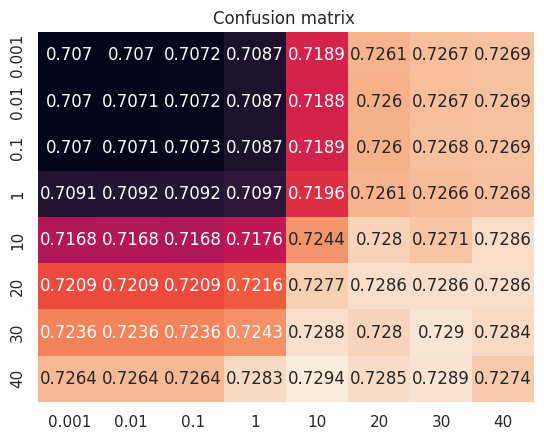

In [ ]:
plot_heatmap(result, ["0.001", "0.01", "0.1", "1", "10", "20", "30", "40"], ["0.001", "0.01", "0.1", "1", "10", "20", "30", "40"])

По этой таблице можно сделать выводы: при маленьких значениях betta и gamma модель обучается хуже. При том видно (правый нижний угол), что при увеличении параметров таблица снова чернеет. То есть при значениях параметров около 20-40 модель имеет лучшние показатели. А именно betta = 40, gamma = 20. Объяснить это можно так: эти коэ-ты по сути штрфы за большие веса. Но логически они похожи. Но все же: раз коэ-ты большие, значит нам важно ругать модель за веса. Значит l1 и l2 в модели важны.

Построим 2 графика: зависимость f1 от разных параметров gamma и зависимость f1 от разных параметров betta

In [ ]:
def plot_f1_dependency_gamma(params, f1_scores):

    fig, ax = plt.subplots()

    for i in range(len(params)):
        ax.plot(params, f1_scores[i])

    ax.set(xlabel='time (s)', ylabel='voltage (mV)', title='About as simple as it gets, folks')
    ax.grid()

    plt.show()

def plot_f1_dependency_betta(params, f1_scores):

    fig, ax = plt.subplots()

    for i in range(len(params)):
        ax.plot(params, np.array(f1_scores)[:, i])

    ax.set(xlabel='time (s)', ylabel='voltage (mV)', title='About as simple as it gets, folks')
    ax.grid()

    plt.show()


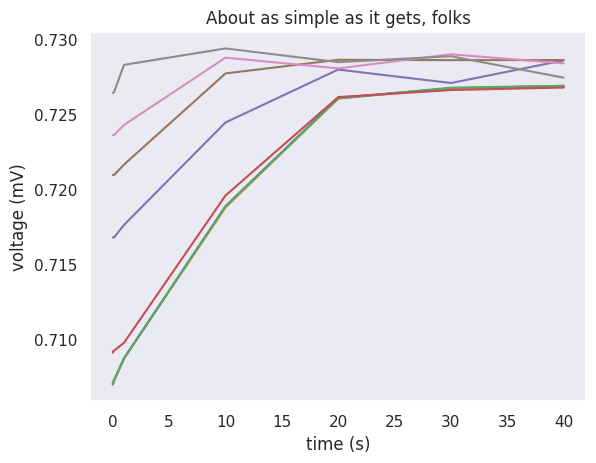

In [ ]:
plot_f1_dependency_gamma(gamma_values, result)

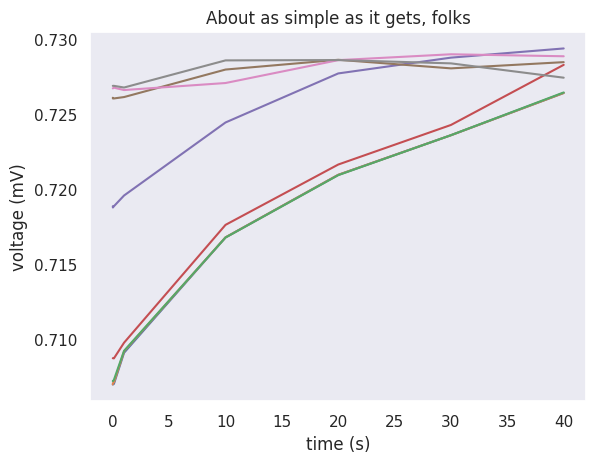

In [ ]:
plot_f1_dependency_betta(gamma_values, result)

На этих графиках показана зависимость f1 от разных показателей betta и gamma.

Тут скорее можно заметить, что betta коэфициент скорее будет расти за пределами наших значений. А вот gamma уже проседает на больших значениях.

Метрики:

In [ ]:
def show_confusion_matrix(test_y, pred, proba):
    print("Precision: {0:6.3f}".format(precision_score(test_y, pred, average='macro')))
    print("Recall: {0:6.3f}".format(recall_score(test_y, pred, average='macro')))
    print("F1-measure: {0:6.3f}".format(f1_score(test_y, pred, average='macro')))
    print("Accuracy: {0:6.3f}".format(accuracy_score(test_y, pred)))
    print('\n')
    labels = ['negative','positive']

    #classification_report
    sns.heatmap(data=confusion_matrix(test_y, pred), annot=True, fmt="d", cbar=False, xticklabels=labels, yticklabels=labels)
    plt.title("Confusion matrix ")
    plt.show()

0.7293766330720418
Precision:  0.641
Recall:  0.526
F1-measure:  0.435
Accuracy:  0.590




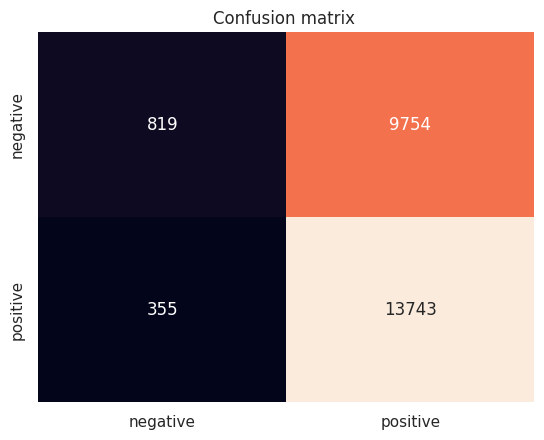

In [ ]:
clf = train_nlp_model(X_train_tfidf, X_test_tfidf, y_train, y_test, betta = 40.0, gamma = 10.0)
pred = clf.predict(np.array(X_train_tfidf.todense()))
proba  = clf.predict_proba(np.array(X_train_tfidf.todense()))
show_confusion_matrix(y_train, pred, proba)

0.7293766330720418
Precision:  0.626
Recall:  0.525
F1-measure:  0.436
Accuracy:  0.589




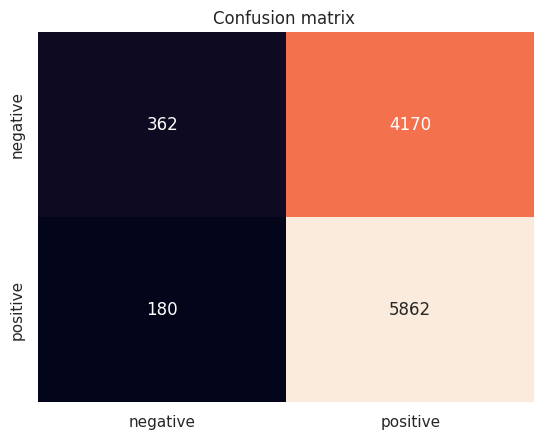

In [ ]:
clf = train_nlp_model(X_train_tfidf, X_test_tfidf, y_train, y_test, betta = 40.0, gamma = 10.0)
pred = clf.predict(np.array(X_test_tfidf.todense()))
proba  = clf.predict_proba(np.array(X_test_tfidf.todense()))
show_confusion_matrix(y_test, pred, proba)

Эти графики показывают heatmap для тренировочных и тестовых данных.

Тут можно сделать такой вывод: если смотреть пропорции, то на тренировочных данных гораздо больше пропорция положительно-положительных срабатываний. (Что в целом логично)

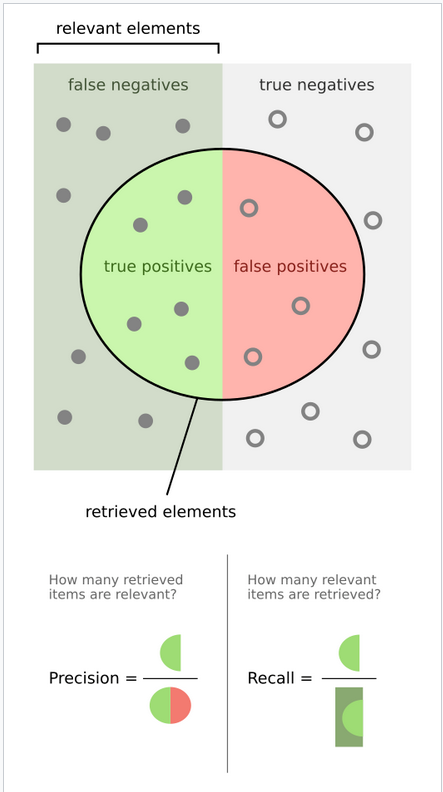

Рассмотрим и сравним метрики:
1. Preciption. По сути показывает, сколько угадано объектов одного класса. Видно что метрика большая и отличается на тестовых и тренировочных данных.
2. Recall. Показывает, какую долю объектов положительного класса из всех объектов положительного класса нашёл алгоритм. Не сильно отличается на 2 выборках, что значит, что модель одинаково ищет объекты положительного класса, притом ищет плохо (значение метрики около 0,5). Но тут надо быть осторожным: мы делили объекты не совсем в равных пропорциях, поэтому она может искуственно выдавать больше предсказаний для одного автора.
3. По сути среднее гармоническое от Preciption и recall. Так же значения не сильно отличаются
4. Accuracy. Просто доля угалданных значений.

#### 9. [1 point] Analysing ROC AUC

It is possible to control the proportion of statistical errors of different types using different thresholds for choosing a class. Plot ROC curves for Logistic Regression and SVC, show the threshold on ROC curve plots. Choose such a threshold that your models have no more than 30% of false positive errors rate. Pay attention to `thresholds` parameter in sklearn roc_curve

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report

model = train_nlp_model(X_train_tfidf, X_test_tfidf, y_train, y_test, betta = 40.0, gamma = 10.0)

y_prob = model.predict_proba(np.array(X_test_tfidf.todense()))[:, 1]
print(y_prob.shape)
print(len(y_test))
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds_lr[optimal_idx]
print("Оптимальный Threshold для модели: ", optimal_threshold)

0.7293766330720418
(10574,)
10574
Оптимальный Threshold для модели:  0.5544406069432722


In [ ]:
def plot_roc_auc_result(tpr_lr, fpr_lr):
    x_axis = list(range(1, len(tpr_lr)+1))
    #y_axis = [thresholds_lr[tpr_lr[i] - fpr_lr[i]] for i in range(len(tpr_lr))]

    fig, ax = plt.subplots()
    ax.plot(x_axis, fpr_lr)
    ax.plot(x_axis, tpr_lr)


    ax.set(xlabel='-', ylabel='fpr, tpr')
    ax.grid()

    plt.show()

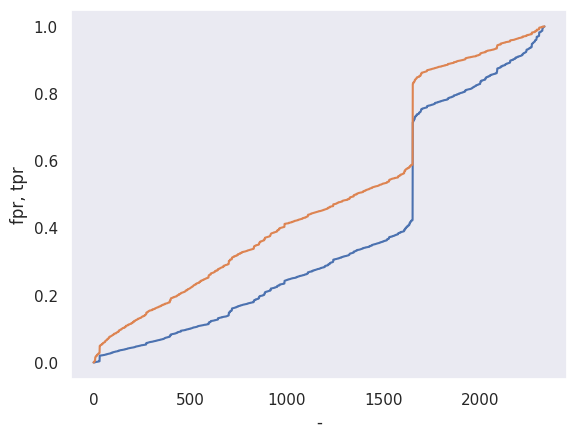

In [ ]:
plot_roc_auc_result(tpr, fpr)

### Multiclass logit

#### 10. [1 point] Take the One-VS-One classifier (use sklearn) and apply to Logit model (one you've made in the 4th task) in order to get multiclass linear classifier

*It is possible to use sklearn model instead of your own one but with a penalty of 0.5*

<a href="https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsOneClassifier.html">OneVsOneClassifier</a>

* use the data you got at the previous step for 6 authors
* divide the data into train and test samples with 0.7 split rate
* using GridSearchCV - find the best parameters for the models (by F1 score)
* plot confusion matrix for train and test samples
* compute relevant metrics for test sample (use sklearn)

In [ ]:
# your code here

In [ ]:
!pip install alive-progress

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.3/207.3 kB 8.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 5.3 MB/s eta 0:00:00
  Created wheel for grapheme: filename=grapheme-0.6.0-py3-none-any.whl size=210082 sha256=7e71bcc02e8853942e5f3420836ee3c162b5ee63bec1240d6478fa3cd393dc99
  Stored in directory: /root/.cache/pip/wheels/01/e1/49/37e6bde9886439057450c494a79b0bef8bbe897a54aebfc757
Successfully built grapheme


ImportError: cannot import name 'showtime' from 'alive_progress' (/usr/local/lib/python3.10/dist-packages/alive_progress/__init__.py)